# Multiprocess a folder and summarize the flux timeseries (MCMC)

Point `data_folder` at a single day's folder of JSON chamber files. The cell below loads the raw data, runs the `Multiprocessor` in MCMC mode across CPU cores, selects the Pareto-optimal (deadband, cutoff) per measurement, and plots the resulting `dcdt(HM)` timeseries with a 16–84 percentile band.

In [13]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('..')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
import logging
import pathlib

import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

from soilgasflux_fcs import Multiprocessor, json_reader

logging.getLogger('soilgasflux_fcs').setLevel(logging.INFO)

In [15]:
# data_folder = pathlib.Path('/Users/alexnaokiasatokobayashi/Documents/data/Gals/2026_tpclass/low-cost sensor/2-2/data/2026-03-19')
data_folder = pathlib.Path('/Users/alexnaokiasatokobayashi/Documents/data/Kerzers/CHYN-Kerzers01/low-cost_sensor/kerzers_20260414/1-1/data/2026-04-02')
output_folder = pathlib.Path('/Users/alexnaokiasatokobayashi/Downloads/test_output')
output_folder.mkdir(parents=True, exist_ok=True)
chamber_id = data_folder.parent.parent.name

In [16]:
initializer = json_reader.Initializer(folderPath=data_folder)
df = initializer.prepare_rawdata()
print(f'{df["id"].nunique()} measurements, {len(df)} rows')
df.head()

92 measurements, 11040 rows


,datetime_utc,si_temperature,bmp_temperature,si_humidity,datetime,k30_co2,bmp_pressure,id,timedelta
0,2026-04-02 00:09:17,1.981373,2.83,95.760868,2026-04-02 00:09:17,519,96803.000,2026-04-02_00-09-17,0
1,2026-04-02 00:09:18,2.002823,2.83,95.684570,2026-04-02 00:09:18,519,96802.670,2026-04-02_00-09-17,1
2,2026-04-02 00:09:20,1.992096,2.83,95.730350,2026-04-02 00:09:20,520,96801.250,2026-04-02_00-09-17,3
3,2026-04-02 00:09:21,2.002823,2.83,95.821900,2026-04-02 00:09:21,521,96802.232,2026-04-02_00-09-17,4
4,2026-04-02 00:09:22,1.992096,2.83,95.837160,2026-04-02 00:09:22,521,96802.410,2026-04-02_00-09-17,5


`run_MC` runs emcee per (deadband, cutoff) window, then `select_bestPareto` picks the Pareto-optimal window per timestamp and writes `<chamber_id>_<date>_bestPareto.nc` into `output_folder`.

In [17]:
processor = Multiprocessor()
ds_mc = processor.run_MC(df=df, 
                         chamber_id=chamber_id, 
                         output_folder=str(output_folder), 
                         sensor_precision=30,
                         n_MC=8000)
ds_mc

INFO soilgasflux_fcs.multiprocess_raw_data: Multiprocessing (MC) started on 14 CPUs
INFO soilgasflux_fcs.multiprocess_raw_data: Processing date 2026-04-02
WARNING soilgasflux_fcs.fcs: HM MC fit failed at deadband=0 cutoff=60: Range exceeds valid bounds
WARNING soilgasflux_fcs.fcs: HM MC fit failed at deadband=0 cutoff=70: Range exceeds valid bounds
WARNING soilgasflux_fcs.fcs: HM MC fit failed at deadband=0 cutoff=80: Range exceeds valid bounds
WARNING soilgasflux_fcs.fcs: HM MC fit failed at deadband=0 cutoff=90: Range exceeds valid bounds
WARNING soilgasflux_fcs.fcs: HM MC fit failed at deadband=0 cutoff=100: Range exceeds valid bounds
WARNING soilgasflux_fcs.fcs: HM MC fit failed at deadband=0 cutoff=110: Range exceeds valid bounds
WARNING soilgasflux_fcs.fcs: HM MC fit failed at deadband=0 cutoff=120: Range exceeds valid bounds
WARNING soilgasflux_fcs.fcs: HM MC fit failed at deadband=0 cutoff=130: Range exceeds valid bounds
WARNING soilgasflux_fcs.fcs: HM MC fit failed at deadband

emcee: Exception while calling your likelihood function:
  params: [8.24942142e-05 3.42216189e+04 3.21700458e+00]
  args: (array([  0,   2,   3,   4,   5,   6,   7,   9,  10,  11,  12,  13,  14,
        16,  17,  18,  19,  20,  21,  23,  24,  25,  26,  27,  28,  30,
        31,  32,  33,  34,  35,  37,  38,  39,  40,  41,  42,  44,  45,
        46,  47,  48,  49,  51,  52,  53,  54,  55,  56,  58,  59,  60,
        61,  62,  64,  65,  66,  67,  68,  69,  71,  72,  73,  74,  75,
        76,  78,  79,  80,  81,  82,  83,  85,  86,  87,  88,  89,  90,
        92,  93,  94,  95,  96,  97,  99, 100, 101, 102, 103, 105, 106,
       107, 108, 109, 110, 112, 113, 114, 115, 116, 117, 119, 120, 121,
       122, 123, 124, 126, 127, 128, 129, 130, 131, 133, 134, 135, 136,
       137, 138, 140]), array([523, 524, 524, 524, 526, 526, 526, 527, 528, 528, 529, 530, 531,
       532, 532, 533, 534, 534, 535, 536, 537, 537, 538, 538, 539, 540,
       541, 542, 543, 544, 545, 546, 547, 548, 549, 550, 550,

Traceback (most recent call last):
  File "/Users/alexnaokiasatokobayashi/.local/share/mamba/envs/FCS/lib/python3.9/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
  File "/Users/alexnaokiasatokobayashi/git/soilgasflux_fcs/notebooks/../soilgasflux_fcs/mcmc.py", line 39, in ln_probability
    return lp + self.ln_likelihood(theta, t, y, yerr, c0)
  File "/Users/alexnaokiasatokobayashi/git/soilgasflux_fcs/notebooks/../soilgasflux_fcs/mcmc.py", line 33, in ln_likelihood
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))
ValueError: operands could not be broadcast together with shapes (120,) (130,) 
WARNING soilgasflux_fcs.fcs: HM MC fit failed at deadband=0 cutoff=130: operands could not be broadcast together with shapes (120,) (130,) 
Traceback (most recent call last):
  File "/Users/alexnaokiasatokobayashi/.local/share/mamba/envs/FCS/lib/python3.9/site-packages/emcee/ensemble.py", line 640, in __call__
    return s

emcee: Exception while calling your likelihood function:
  params: [2.89095432e-02 5.85440811e+01 4.09025300e+01]
  args: (array([  0,   1,   2,   3,   4,   6,   7,   8,   9,  10,  11,  13,  14,
        15,  16,  17,  19,  20,  21,  22,  23,  24,  26,  27,  28,  29,
        30,  31,  33,  34,  35,  36,  37,  38,  40,  41,  42,  43,  44,
        45,  47,  48,  49,  50,  51,  52,  54,  55,  56,  57,  58,  60,
        61,  62,  63,  64,  65,  67,  68,  69,  70,  71,  72,  74,  75,
        76,  77,  78,  79,  81,  82,  83,  84,  85,  86,  88,  89,  90,
        91,  92,  93,  95,  96,  97,  98,  99, 100, 102, 103, 104, 105,
       106, 108, 109, 110, 111, 112, 113, 115, 116, 117, 118, 119, 120,
       122, 123, 124, 125, 126, 127, 129, 130, 131, 132, 133, 134, 136,
       137, 138, 139]), array([516, 516, 516, 516, 517, 517, 518, 518, 520, 521, 521, 523, 523,
       524, 525, 526, 527, 527, 527, 528, 529, 530, 531, 532, 532, 533,
       533, 534, 534, 535, 535, 536, 537, 538, 538, 539, 540,

Traceback (most recent call last):
  File "/Users/alexnaokiasatokobayashi/.local/share/mamba/envs/FCS/lib/python3.9/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
  File "/Users/alexnaokiasatokobayashi/git/soilgasflux_fcs/notebooks/../soilgasflux_fcs/mcmc.py", line 39, in ln_probability
    return lp + self.ln_likelihood(theta, t, y, yerr, c0)
  File "/Users/alexnaokiasatokobayashi/git/soilgasflux_fcs/notebooks/../soilgasflux_fcs/mcmc.py", line 33, in ln_likelihood
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))
ValueError: operands could not be broadcast together with shapes (120,) (130,) 
WARNING soilgasflux_fcs.fcs: HM MC fit failed at deadband=0 cutoff=130: operands could not be broadcast together with shapes (120,) (130,) 
Traceback (most recent call last):
  File "/Users/alexnaokiasatokobayashi/.local/share/mamba/envs/FCS/lib/python3.9/site-packages/emcee/ensemble.py", line 640, in __call__
    return s

...

emcee: Exception while calling your likelihood function:
  params: [5.19741772e-05 3.53837088e+01 9.58946443e+00]
  args: (array([ 58,  59,  61,  62,  63,  64,  65,  66,  68,  69,  70,  71,  72,
        73,  75,  76,  77,  78,  79,  80,  82,  83,  84,  85,  86,  87,
        89,  90,  91,  92,  94,  95,  96,  98,  99, 101, 102, 104, 105,
       107, 108, 109, 111, 112, 114, 115, 117, 118, 120, 121, 123, 124,
       125, 127, 128, 130, 131, 133, 134, 135, 136, 137, 138, 140, 141,
       142, 143, 144, 145, 147]), array([698, 700, 702, 704, 705, 707, 708, 710, 711, 712, 713, 715, 716,
       717, 719, 720, 721, 722, 722, 723, 724, 726, 727, 728, 729, 729,
       730, 731, 731, 733, 735, 737, 739, 741, 741, 742, 744, 745, 745,
       746, 747, 748, 748, 750, 752, 752, 754, 756, 758, 758, 759, 760,
       761, 763, 764, 766, 767, 768, 770, 772, 772, 774, 775, 776, 777,
       777, 778, 780, 780, 780]), array([30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30.,
       30., 30., 

Traceback (most recent call last):
  File "/Users/alexnaokiasatokobayashi/.local/share/mamba/envs/FCS/lib/python3.9/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
  File "/Users/alexnaokiasatokobayashi/git/soilgasflux_fcs/notebooks/../soilgasflux_fcs/mcmc.py", line 39, in ln_probability
    return lp + self.ln_likelihood(theta, t, y, yerr, c0)
  File "/Users/alexnaokiasatokobayashi/git/soilgasflux_fcs/notebooks/../soilgasflux_fcs/mcmc.py", line 33, in ln_likelihood
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))
ValueError: operands could not be broadcast together with shapes (70,) (80,) 
WARNING soilgasflux_fcs.fcs: HM MC fit failed at deadband=50 cutoff=130: operands could not be broadcast together with shapes (70,) (80,) 
Traceback (most recent call last):
  File "/Users/alexnaokiasatokobayashi/.local/share/mamba/envs/FCS/lib/python3.9/site-packages/emcee/ensemble.py", line 640, in __call__
    return self

emcee: Exception while calling your likelihood function:
  params: [9.63154773e-04 1.22409107e+03 5.93372960e+01]
  args: (array([ 58,  60,  61,  62,  63,  64,  65,  67,  68,  69,  70,  71,  72,
        74,  75,  76,  77,  79,  80,  82,  83,  84,  86,  87,  89,  90,
        92,  93,  95,  96,  97,  99, 100, 102, 103, 105, 106, 107, 109,
       110, 112, 113, 114, 116, 117, 118, 119, 120, 121, 123, 124, 125,
       126, 127, 128, 130, 131, 132, 133, 134, 135, 137, 138, 139, 140,
       141, 143, 144, 145, 146]), array([714, 715, 717, 719, 720, 720, 721, 723, 724, 725, 726, 727, 728,
       730, 731, 732, 734, 736, 738, 739, 740, 741, 743, 745, 746, 747,
       749, 751, 752, 754, 755, 757, 758, 759, 761, 762, 763, 765, 765,
       766, 767, 768, 771, 771, 773, 775, 776, 777, 779, 779, 780, 781,
       782, 784, 784, 785, 785, 786, 787, 787, 789, 790, 791, 793, 793,
       795, 797, 797, 798, 798]), array([30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30.,
       30., 30., 

Traceback (most recent call last):
  File "/Users/alexnaokiasatokobayashi/.local/share/mamba/envs/FCS/lib/python3.9/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
  File "/Users/alexnaokiasatokobayashi/git/soilgasflux_fcs/notebooks/../soilgasflux_fcs/mcmc.py", line 39, in ln_probability
    return lp + self.ln_likelihood(theta, t, y, yerr, c0)
  File "/Users/alexnaokiasatokobayashi/git/soilgasflux_fcs/notebooks/../soilgasflux_fcs/mcmc.py", line 33, in ln_likelihood
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))
ValueError: operands could not be broadcast together with shapes (70,) (80,) 
WARNING soilgasflux_fcs.fcs: HM MC fit failed at deadband=50 cutoff=130: operands could not be broadcast together with shapes (70,) (80,) 
Traceback (most recent call last):
  File "/Users/alexnaokiasatokobayashi/.local/share/mamba/envs/FCS/lib/python3.9/site-packages/emcee/ensemble.py", line 640, in __call__
    return self

<xarray.Dataset> Size: 1GB
Dimensions:      (time: 92, cutoff: 10, deadband: 6, MC: 8000)
Coordinates:
  * time         (time) datetime64[ns] 736B 2026-04-02T00:09:17 ... 2026-04-0...
  * deadband     (deadband) int64 48B 0 10 20 30 40 50
  * cutoff       (cutoff) int64 80B 60 70 80 90 100 110 120 130 140 150
  * MC           (MC) int64 64kB 0 1 2 3 4 5 6 ... 7994 7995 7996 7997 7998 7999
Data variables:
    dcdt(HM)     (time, cutoff, deadband, MC) float32 177MB 1.312 1.3 ... nan
    AIC(HM)      (time, cutoff, deadband, MC) float32 177MB 248.2 330.9 ... nan
    RMSE(HM)     (time, cutoff, deadband, MC) float32 177MB 7.278 14.5 ... nan
    R2(HM)       (time, cutoff, deadband, MC) float32 177MB -1.751e+03 ... nan
    nRMSE(HM)    (time, cutoff, deadband, MC) float32 177MB 0.1055 ... nan
    logprob(HM)  (time, cutoff, deadband, MC) float32 177MB -205.1 ... nan

In [18]:
pareto_files = sorted(output_folder.glob(f'{chamber_id}_*_bestPareto.nc'))
ds_best = xr.open_mfdataset(pareto_files, combine='by_coords').sortby('time')
ds_best

<xarray.Dataset> Size: 5MB
Dimensions:        (time: 142, MC: 8000)
Coordinates:
  * MC             (MC) int64 64kB 0 1 2 3 4 5 ... 7994 7995 7996 7997 7998 7999
  * time           (time) datetime64[ns] 1kB 2026-04-01T10:30:43 ... 2026-04-...
Data variables:
    dcdt(HM)       (time, MC) float32 5MB dask.array<chunksize=(71, 8000), meta=np.ndarray>
    best_deadband  (time) int64 1kB dask.array<chunksize=(71,), meta=np.ndarray>
    best_cutoff    (time) int64 1kB dask.array<chunksize=(71,), meta=np.ndarray>

In [19]:
dcdt = ds_best['dcdt(HM)']
median = dcdt.median(dim='MC')
q16 = dcdt.quantile(0.16, dim='MC')
q84 = dcdt.quantile(0.84, dim='MC')

summary = pd.DataFrame({
    'time': ds_best['time'].values,
    'dcdt_median': median.values,
    'dcdt_q16': q16.values,
    'dcdt_q84': q84.values,
    'best_deadband': ds_best['best_deadband'].values,
    'best_cutoff': ds_best['best_cutoff'].values,
}).set_index('time')
summary.describe()

,dcdt_median,dcdt_q16,dcdt_q84,best_deadband,best_cutoff
count,142.000000,142.000000,142.000000,142.000000,142.000000
mean,0.555400,0.451777,0.680845,19.577465,90.140845
std,0.369999,0.326854,0.380625,16.017421,16.673158
min,0.000000,0.000000,0.000000,0.000000,60.000000
25%,0.364604,0.256012,0.479576,10.000000,80.000000
50%,0.580530,0.437001,0.707018,20.000000,90.000000
75%,0.805628,0.662369,0.940303,30.000000,100.000000
max,1.546220,1.424819,1.657068,50.000000,120.000000


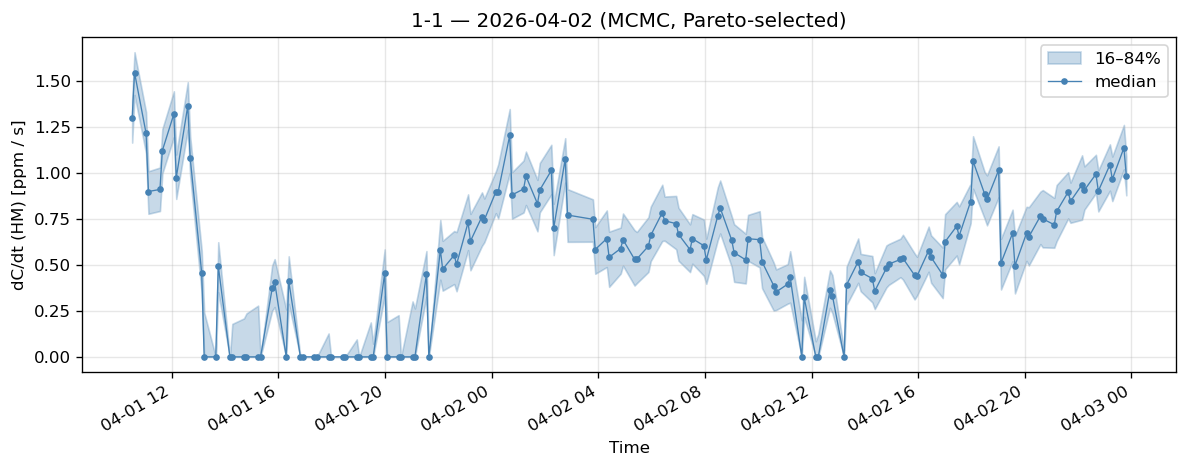

In [20]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=120)
ax.fill_between(summary.index, summary['dcdt_q16'], summary['dcdt_q84'],
                color='steelblue', alpha=0.3, label='16–84%')
ax.plot(summary.index, summary['dcdt_median'], color='steelblue',
        marker='o', ms=3, lw=0.8, label='median')
ax.set_xlabel('Time')
ax.set_ylabel('dC/dt (HM) [ppm / s]')
ax.set_title(f'{chamber_id} — {data_folder.name} (MCMC, Pareto-selected)')
ax.grid(alpha=0.3)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()